# 06 — Advanced Modeling

## Purpose

This notebook performs **advanced feature-based regression modeling** for pasture biomass
prediction, building directly on the validated feature table produced in Notebook 05
(`combined_features_with_visual.csv`).

Notebook 04 established baseline performance using Ridge regression and Random Forest with
CNN-only, metadata-only, and CNN+metadata feature combinations. Notebook 05 then engineered a
set of handcrafted visual features (vegetation proxy coverage, color statistics, texture, and
structural edge-density descriptors) derived from heuristic, rule-based proxies — not learned
segmentation.

This notebook asks whether:

1. **Handcrafted visual features** provide complementary predictive signal on top of frozen
   EfficientNetB0 embeddings and metadata.
2. **Stronger tree-based ensemble and boosting models** (Extra Trees, LightGBM, XGBoost, and
   optionally CatBoost) outperform the Notebook 04 Ridge/Random Forest baselines.
3. Which **feature configuration** (visual-only vs. all-features) performs best.
4. Which **advanced model** performs best overall.
5. Which biomass targets are **easiest and hardest** to predict.
6. Which configuration should proceed to **Notebook 07** for deep learning comparison and
   ensemble modeling.

## Why tree-based ensembles and boosting models?

With only 357 unique images and 1280-dimensional CNN embeddings, the sample-to-feature ratio is
low. Tree-based ensembles (Extra Trees) and gradient boosting methods (LightGBM, XGBoost,
CatBoost) are well suited to this regime: they handle high-dimensional, heterogeneous feature
sets without requiring feature scaling, are relatively robust to irrelevant features, and provide
built-in feature importance for interpretability.

## Why a focused experiment design?

Given the small sample size, an exhaustive grid across every model and every feature-set
combination would multiply computational cost and increase the risk of overfitting to
cross-validation noise through repeated model selection. Instead, this notebook runs a small,
deliberately chosen set of experiments that directly test the two central questions above (visual
feature value, and advanced-model-vs-baseline performance).

## Why 5-fold cross-validation and out-of-fold (OOF) predictions?

The existing 5-fold assignments (created in Notebook 02) are preserved throughout. Cross-validated
out-of-fold predictions are used for every metric in this notebook to avoid target leakage and to
ensure that reported performance reflects genuine generalization rather than in-sample fit.


In [2]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# --- Safely add PROJECT_ROOT to sys.path ---
PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
while not (PROJECT_ROOT_CANDIDATE / "src").exists() and PROJECT_ROOT_CANDIDATE.parent != PROJECT_ROOT_CANDIDATE:
    PROJECT_ROOT_CANDIDATE = PROJECT_ROOT_CANDIDATE.parent

if str(PROJECT_ROOT_CANDIDATE) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_CANDIDATE)) 

from src.config import (
    PROJECT_ROOT,
    FEATURE_TABLE_DIR,
    REPORTS_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR,
    ADVANCED_MODEL_DIR,
    EXTRA_TREES_MODEL_DIR,
    ADVANCED_LGBM_MODEL_DIR,
    XGBOOST_MODEL_DIR,
    CATBOOST_MODEL_DIR,
    ADVANCED_FIGURES_DIR,
    RANDOM_SEED,
    N_FOLDS,
)

from src.modeling import TARGET_COLUMNS

from src.advanced_modeling import (
    identify_advanced_feature_columns,
    validate_advanced_feature_table,
    build_extra_trees_model,
    build_hist_gradient_boosting_model,
    build_lightgbm_model,
    build_xgboost_model,
    build_catboost_model,
    calculate_advanced_regression_metrics,
    run_advanced_cross_validation,
    summarize_advanced_cv_results,
    rank_model_configurations,
    validate_advanced_oof_predictions,
    save_oof_predictions,
)

print("=" * 60)
print("NOTEBOOK 06 - ADVANCED MODELING - ENVIRONMENT SETUP")
print("=" * 60)
print(f"Project Root            : {PROJECT_ROOT}")
print(f"Random Seed             : {RANDOM_SEED}")
print(f"Number of Folds         : {N_FOLDS}")
print(f"Target Columns          : {TARGET_COLUMNS}")
print("src.advanced_modeling module imported successfully.")


NOTEBOOK 06 - ADVANCED MODELING - ENVIRONMENT SETUP
Project Root            : E:\DATAVIDWAN\Image2Biomass
Random Seed             : 42
Number of Folds         : 5
Target Columns          : ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
src.advanced_modeling module imported successfully.


In [3]:
import platform

print("=" * 60)
print("DEPENDENCY CHECK")
print("=" * 60)

print(f"Python      : {platform.python_version()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

import sklearn
print(f"scikit-learn: {sklearn.__version__}")

# --- LightGBM ---
try:
    import lightgbm
    LIGHTGBM_AVAILABLE = True
    print(f"LightGBM    : {lightgbm.__version__} (available)")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM    : NOT AVAILABLE (experiments using LightGBM will be skipped)")

# --- XGBoost ---
try:
    import xgboost
    XGBOOST_AVAILABLE = True
    print(f"XGBoost     : {xgboost.__version__} (available)")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost     : NOT AVAILABLE (experiments using XGBoost will be skipped)")

# --- CatBoost (optional) ---
try:
    import catboost
    CATBOOST_AVAILABLE = True
    print(f"CatBoost    : {catboost.__version__} (available, optional experiment enabled)")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost    : NOT AVAILABLE (optional experiment will be skipped)")

print("=" * 60)
print("Dependency check complete.")
print("=" * 60)


DEPENDENCY CHECK
Python      : 3.13.5
NumPy       : 2.1.3
Pandas      : 2.2.3
scikit-learn: 1.6.1
LightGBM    : 4.6.0 (available)
XGBoost     : 3.1.2 (available)
CatBoost    : 1.2.10 (available, optional experiment enabled)
Dependency check complete.


In [4]:
print("=" * 60)
print("LOADING EXISTING PROJECT ARTIFACTS")
print("=" * 60)

FEATURE_TABLE_PATH = FEATURE_TABLE_DIR / "combined_features_with_visual.csv"
BASELINE_CV_SUMMARY_PATH = REPORTS_DIR / "baseline_cv_summary.csv"
BASELINE_FOLD_METRICS_PATH = REPORTS_DIR / "baseline_fold_metrics.csv"
BASELINE_MODEL_RANKINGS_PATH = REPORTS_DIR / "baseline_model_ranking.csv"
BEST_BASELINE_MODELS_PATH = REPORTS_DIR / "best_baseline_models_per_target.csv"

required_artifacts = {
    FEATURE_TABLE_PATH: "Notebook 05 (visual feature integration)",
    BASELINE_CV_SUMMARY_PATH: "Notebook 04 (baseline modeling)",
    BASELINE_FOLD_METRICS_PATH: "Notebook 04 (baseline modeling)",
    BASELINE_MODEL_RANKINGS_PATH: "Notebook 04 (baseline modeling)",
    BEST_BASELINE_MODELS_PATH: "Notebook 04 (baseline modeling)",
}

for path, source_notebook in required_artifacts.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Required artifact missing: {path}\n"
            f"This artifact should be regenerated by re-running {source_notebook}."
        )

advanced_feature_table = pd.read_csv(FEATURE_TABLE_PATH)
baseline_cv_summary = pd.read_csv(BASELINE_CV_SUMMARY_PATH)
baseline_fold_metrics = pd.read_csv(BASELINE_FOLD_METRICS_PATH)
baseline_model_rankings = pd.read_csv(BASELINE_MODEL_RANKINGS_PATH)
best_baseline_models_per_target = pd.read_csv(BEST_BASELINE_MODELS_PATH)

print(f"Advanced feature table shape        : {advanced_feature_table.shape}")
print(f"Baseline CV summary shape           : {baseline_cv_summary.shape}")
print(f"Baseline fold metrics shape         : {baseline_fold_metrics.shape}")
print(f"Baseline model rankings shape       : {baseline_model_rankings.shape}")
print(f"Best baseline models per target shape: {best_baseline_models_per_target.shape}")

advanced_feature_table.head()


LOADING EXISTING PROJECT ARTIFACTS
Advanced feature table shape        : (357, 1397)
Baseline CV summary shape           : (30, 9)
Baseline fold metrics shape         : (150, 7)
Baseline model rankings shape       : (6, 6)
Best baseline models per target shape: (5, 6)


,image_path,processed_image_path,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,cnn_0000,cnn_0001,...,hist_v_12,hist_v_13,hist_v_14,hist_v_15,texture_contrast,texture_dissimilarity,texture_homogeneity,texture_energy,texture_correlation,edge_density
0,train/ID1011485656.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,31.9984,16.2751,48.2735,16.2750,-0.129528,-0.114636,...,0.033001,0.014698,0.006298,0.002075,23.934295,3.547916,0.310362,0.068177,0.577699,0.327408
1,train/ID1012260530.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,4,0.0000,0.0000,7.6000,7.6000,7.6000,0.230389,-0.185907,...,0.041218,0.039139,0.032295,0.008335,28.876086,3.677744,0.340214,0.070215,0.692363,0.274742
2,train/ID1025234388.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,1,6.0500,0.0000,0.0000,6.0500,6.0500,0.078159,-0.212043,...,0.007107,0.002220,0.003796,0.002079,17.557865,2.983560,0.351393,0.081723,0.597667,0.309174
3,train/ID1028611175.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,30.9703,24.2376,55.2079,24.2376,-0.132350,-0.141714,...,0.038700,0.023270,0.012405,0.006832,26.531423,3.723646,0.303200,0.067834,0.550522,0.326389
4,train/ID1035947949.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,0,0.4343,23.2239,10.5261,34.1844,10.9605,-0.170238,-0.080727,...,0.004421,0.001087,0.000210,0.000053,11.122820,2.392842,0.388580,0.106848,0.500605,0.309944


In [5]:
print("=" * 60)
print("VERIFY EXISTING FEATURE INTEGRATION (NO RE-MERGING)")
print("=" * 60)

feature_columns_info = identify_advanced_feature_columns(advanced_feature_table)

cnn_features = feature_columns_info["cnn"]
metadata_features = feature_columns_info["metadata"]
visual_features = feature_columns_info["visual"]
all_predictive_features = feature_columns_info["all_features"]

assert "image_path" in advanced_feature_table.columns, "image_path column missing."
assert "fold" in advanced_feature_table.columns, "fold column missing."
for target in TARGET_COLUMNS:
    assert target in advanced_feature_table.columns, f"Missing target column: {target}"

n_samples = len(advanced_feature_table)
n_folds_found = advanced_feature_table["fold"].nunique()
n_duplicate_paths = advanced_feature_table["image_path"].duplicated().sum()

print(f"Table shape                 : {advanced_feature_table.shape}")
print(f"CNN feature count           : {len(cnn_features)}")
print(f"Metadata feature count      : {len(metadata_features)}")
print(f"Visual feature count        : {len(visual_features)}")
print(f"Total predictive feature count: {len(all_predictive_features)}")
print(f"Target count                : {len(TARGET_COLUMNS)}")
print(f"Fold count                  : {n_folds_found}")
print(f"Duplicate image path count  : {n_duplicate_paths}")

assert n_samples == 357, f"Expected 357 samples, found {n_samples}"
assert n_folds_found == N_FOLDS, f"Expected {N_FOLDS} folds, found {n_folds_found}"
assert n_duplicate_paths == 0, "Duplicate image paths detected."

feature_group_summary = pd.DataFrame([
    {"Feature Group": "CNN", "Feature Count": len(cnn_features)},
    {"Feature Group": "Metadata", "Feature Count": len(metadata_features)},
    {"Feature Group": "Visual", "Feature Count": len(visual_features)},
    {"Feature Group": "Total Predictive", "Feature Count": len(all_predictive_features)},
])
feature_group_summary


VERIFY EXISTING FEATURE INTEGRATION (NO RE-MERGING)
Table shape                 : (357, 1397)
CNN feature count           : 1280
Metadata feature count      : 21
Visual feature count        : 88
Total predictive feature count: 1389
Target count                : 5
Fold count                  : 5
Duplicate image path count  : 0


,Feature Group,Feature Count
0,CNN,1280
1,Metadata,21
2,Visual,88
3,Total Predictive,1389


In [6]:
print("=" * 60)
print("FINAL ADVANCED FEATURE TABLE VALIDATION")
print("=" * 60)

validation_results = validate_advanced_feature_table(
    advanced_feature_table
)

# Duplicate-path validation is not returned by
# validate_advanced_feature_table(), so calculate it separately.
duplicate_image_paths = int(
    advanced_feature_table["image_path"].duplicated().sum()
)

print("=" * 60)
print("ADVANCED FEATURE TABLE INTEGRITY VALIDATION")
print("=" * 60)

print(f"Samples                    : {validation_results['n_samples']}")
print(f"CNN Features               : {validation_results['n_cnn_features']}")
print(f"Metadata Features          : {validation_results['n_metadata_features']}")
print(f"Visual Features            : {validation_results['n_visual_features']}")
print(f"Total Predictive Features  : {validation_results['n_total_features']}")
print(f"Target Columns             : {validation_results['n_targets']}")
print(f"Cross-Validation Folds     : {validation_results['n_folds']}")

print()

print(f"NaN Predictive Values      : {validation_results['predictive_nan_count']}")
print(f"Infinite Predictive Values : {validation_results['predictive_inf_count']}")
print(f"NaN Target Values          : {validation_results['target_nan_count']}")
print(f"Infinite Target Values     : {validation_results['target_inf_count']}")
print(f"Duplicate Image Paths      : {duplicate_image_paths}")

# ============================================================
# INTEGRITY ASSERTIONS
# ============================================================

assert validation_results["n_samples"] == 357, (
    f"Expected 357 samples, received "
    f"{validation_results['n_samples']}."
)

assert validation_results["n_folds"] == N_FOLDS, (
    f"Expected {N_FOLDS} folds, received "
    f"{validation_results['n_folds']}."
)

assert validation_results["n_targets"] == len(TARGET_COLUMNS), (
    f"Expected {len(TARGET_COLUMNS)} targets, received "
    f"{validation_results['n_targets']}."
)

assert validation_results["predictive_nan_count"] == 0

assert validation_results["predictive_inf_count"] == 0

assert validation_results["target_nan_count"] == 0

assert validation_results["target_inf_count"] == 0

assert duplicate_image_paths == 0

print()
print("Advanced feature table validated successfully.")

FINAL ADVANCED FEATURE TABLE VALIDATION
ADVANCED FEATURE TABLE INTEGRITY VALIDATION
Samples                    : 357
CNN Features               : 1280
Metadata Features          : 21
Visual Features            : 88
Total Predictive Features  : 1389
Target Columns             : 5
Cross-Validation Folds     : 5

NaN Predictive Values      : 0
Infinite Predictive Values : 0
NaN Target Values          : 0
Infinite Target Values     : 0
Duplicate Image Paths      : 0

Advanced feature table validated successfully.


FEATURE GROUP ANALYSIS
         Feature Set  Feature Count
0                CNN           1280
1           Metadata             21
2             Visual             88
3     CNN + Metadata           1301
4       CNN + Visual           1368
5  Metadata + Visual            109
6       All Features           1389


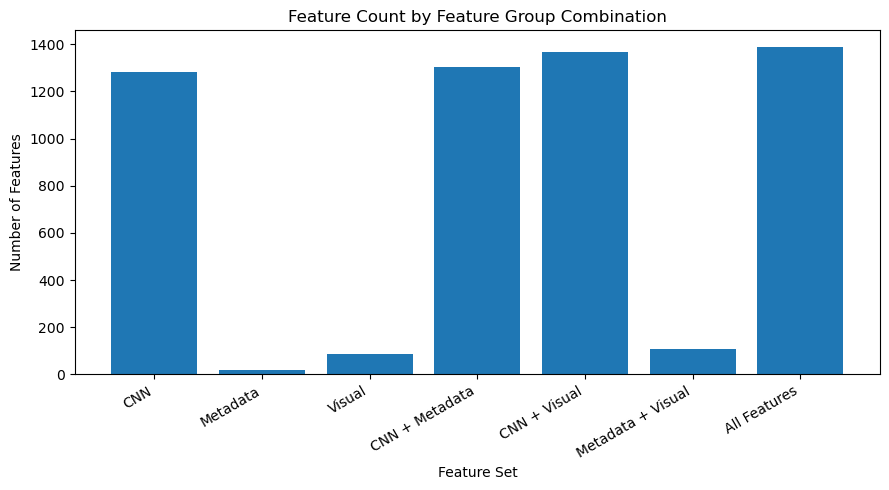

Saved figure: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_feature_group_counts.png


In [7]:
print("=" * 60)
print("FEATURE GROUP ANALYSIS")
print("=" * 60)

# Ensure Notebook 06 figure directory exists
ADVANCED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

feature_group_combinations = {
    "CNN": cnn_features,
    "Metadata": metadata_features,
    "Visual": visual_features,
    "CNN + Metadata": cnn_features + metadata_features,
    "CNN + Visual": cnn_features + visual_features,
    "Metadata + Visual": metadata_features + visual_features,
    "All Features": all_predictive_features,
}

feature_group_counts = pd.DataFrame([
    {
        "Feature Set": name,
        "Feature Count": len(cols),
    }
    for name, cols in feature_group_combinations.items()
])

print(feature_group_counts)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    feature_group_counts["Feature Set"],
    feature_group_counts["Feature Count"],
)

ax.set_title("Feature Count by Feature Group Combination")
ax.set_xlabel("Feature Set")
ax.set_ylabel("Number of Features")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = (
    ADVANCED_FIGURES_DIR
    / "06_feature_group_counts.png"
)

fig.savefig(
    fig_path,
    dpi=150,
)

plt.show()

print(f"Saved figure: {fig_path}")

## Experiment Design Rationale

Only 357 unique images are available, while the CNN embedding alone contributes 1280 features.
This is a high feature-to-sample ratio. Running an exhaustive combination of every model against
every feature set would substantially increase computation time and the risk of selecting a
configuration that merely overfits cross-validation folds through repeated comparisons, rather
than reflecting a genuine generalization advantage.

Instead, this notebook runs a **focused set of experiments** that directly target the two central
research questions (value of visual features, and advanced-model-vs-baseline performance):

**Primary experiments**

1. Extra Trees + Visual features only
2. Extra Trees + All features (CNN + metadata + visual)
3. LightGBM + Visual features only
4. LightGBM + All features
5. XGBoost + All features

**Optional experiment** (included only if the dependency is installed)

6. CatBoost + All features

Comparing "Visual only" against "All features" for both Extra Trees and LightGBM directly tests
whether visual features add value in isolation and in combination with the stronger CNN/metadata
signal, while keeping the total number of experiments small and interpretable.


In [8]:
print("=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)

experiment_configs = []

# ============================================================
# 1. EXTRA TREES + VISUAL FEATURES
# ============================================================

experiment_configs.append({
    "model_name": "ExtraTrees",
    "feature_set_name": "Visual",
    "feature_columns": visual_features,
    "model_builder": lambda: build_extra_trees_model(),
    "use_multioutput_wrapper": False,
})


# ============================================================
# 2. EXTRA TREES + ALL FEATURES
# ============================================================

experiment_configs.append({
    "model_name": "ExtraTrees",
    "feature_set_name": "All_Features",
    "feature_columns": all_predictive_features,
    "model_builder": lambda: build_extra_trees_model(),
    "use_multioutput_wrapper": False,
})


# ============================================================
# 3–4. LIGHTGBM EXPERIMENTS
# ============================================================

if LIGHTGBM_AVAILABLE:

    experiment_configs.append({
        "model_name": "LightGBM",
        "feature_set_name": "Visual",
        "feature_columns": visual_features,
        "model_builder": lambda: build_lightgbm_model(),
        "use_multioutput_wrapper": True,
    })

    experiment_configs.append({
        "model_name": "LightGBM",
        "feature_set_name": "All_Features",
        "feature_columns": all_predictive_features,
        "model_builder": lambda: build_lightgbm_model(),
        "use_multioutput_wrapper": True,
    })

else:

    print(
        "Skipping LightGBM experiments "
        "(dependency not available)."
    )


# ============================================================
# 5. XGBOOST + ALL FEATURES
# ============================================================

if XGBOOST_AVAILABLE:

    experiment_configs.append({
        "model_name": "XGBoost",
        "feature_set_name": "All_Features",
        "feature_columns": all_predictive_features,
        "model_builder": lambda: build_xgboost_model(),
        "use_multioutput_wrapper": True,
    })

else:

    print(
        "Skipping XGBoost experiment "
        "(dependency not available)."
    )


# ============================================================
# 6. CATBOOST + ALL FEATURES (OPTIONAL)
# ============================================================

if CATBOOST_AVAILABLE:

    experiment_configs.append({
        "model_name": "CatBoost",
        "feature_set_name": "All_Features",
        "feature_columns": all_predictive_features,
        "model_builder": lambda: build_catboost_model(),
        "use_multioutput_wrapper": True,
    })

else:

    print(
        "Skipping optional CatBoost experiment "
        "(dependency not available)."
    )


# ============================================================
# DISPLAY EXPERIMENT CONFIGURATION
# ============================================================

experiment_config_display = pd.DataFrame([
    {
        "Experiment #": i + 1,
        "Model": cfg["model_name"],
        "Feature Set": cfg["feature_set_name"],
        "Number of Features": len(
            cfg["feature_columns"]
        ),
        "Requires MultiOutputRegressor":
            cfg["use_multioutput_wrapper"],
    }
    for i, cfg in enumerate(experiment_configs)
])

print()
print(
    f"Total configured experiments: "
    f"{len(experiment_configs)}"
)

experiment_config_display

EXPERIMENT CONFIGURATION

Total configured experiments: 6


,Experiment #,Model,Feature Set,Number of Features,Requires MultiOutputRegressor
0,1,ExtraTrees,Visual,88,False
1,2,ExtraTrees,All_Features,1389,False
2,3,LightGBM,Visual,88,True
3,4,LightGBM,All_Features,1389,True
4,5,XGBoost,All_Features,1389,True
5,6,CatBoost,All_Features,1389,True


In [9]:
print("=" * 60)
print("RUNNING ADVANCED CROSS-VALIDATION EXPERIMENTS")
print("=" * 60)

experiment_oof_predictions = {}
experiment_fold_metrics = {}
experiment_models = {}
experiment_runtimes = {}

for cfg in experiment_configs:

    exp_key = (
        f"{cfg['model_name']}__"
        f"{cfg['feature_set_name']}"
    )

    print()
    print("-" * 60)
    print(
        f"Running experiment: {exp_key} "
        f"({len(cfg['feature_columns'])} features)"
    )
    print("-" * 60)

    start_time = time.time()

    oof_predictions, fold_metrics, fitted_models = (
        run_advanced_cross_validation(
            feature_table=advanced_feature_table,
            feature_columns=cfg["feature_columns"],
            model_builder=cfg["model_builder"],
            model_name=cfg["model_name"],
            feature_set_name=cfg["feature_set_name"],
            fold_column="fold",
            target_columns=TARGET_COLUMNS,
            use_multioutput_wrapper=cfg[
                "use_multioutput_wrapper"
            ],
            clip_negative_predictions=True,
            save_models=False,
        )
    )

    elapsed = time.time() - start_time

    experiment_oof_predictions[
        exp_key
    ] = oof_predictions

    experiment_fold_metrics[
        exp_key
    ] = fold_metrics

    experiment_models[
        exp_key
    ] = fitted_models

    experiment_runtimes[
        exp_key
    ] = elapsed

    print(f"Completed in {elapsed:.1f}s")


print()
print("=" * 60)
print(
    f"All {len(experiment_configs)} "
    f"experiments completed."
)
print("=" * 60)

RUNNING ADVANCED CROSS-VALIDATION EXPERIMENTS

------------------------------------------------------------
Running experiment: ExtraTrees__Visual (88 features)
------------------------------------------------------------
Completed in 3.1s

------------------------------------------------------------
Running experiment: ExtraTrees__All_Features (1389 features)
------------------------------------------------------------
Completed in 30.8s

------------------------------------------------------------
Running experiment: LightGBM__Visual (88 features)
------------------------------------------------------------


e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid featur

Completed in 6.2s

------------------------------------------------------------
Running experiment: LightGBM__All_Features (1389 features)
------------------------------------------------------------


e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid featur

Completed in 38.7s

------------------------------------------------------------
Running experiment: XGBoost__All_Features (1389 features)
------------------------------------------------------------
Completed in 515.0s

------------------------------------------------------------
Running experiment: CatBoost__All_Features (1389 features)
------------------------------------------------------------
Completed in 1145.1s

All 6 experiments completed.


In [10]:
print("=" * 60)
print("VALIDATING ALL OOF PREDICTIONS")
print("=" * 60)

oof_validation_rows = []

for exp_key, predictions in experiment_oof_predictions.items():

    model_name, feature_set_name = exp_key.split("__")

    validation = validate_advanced_oof_predictions(
        predictions=predictions,
        expected_samples=len(advanced_feature_table),
        expected_targets=len(TARGET_COLUMNS),
    )

    oof_validation_rows.append({
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Samples": validation["n_samples"],
        "Targets": validation["n_targets"],
        "NaN Count": validation["nan_count"],
        "Infinite Count": validation["inf_count"],
        "Negative Predictions": validation["negative_prediction_count"],
        "Prediction Min": validation["prediction_min"],
        "Prediction Max": validation["prediction_max"],
        "Prediction Mean": round(validation["prediction_mean"], 4),
        "Prediction Std": round(validation["prediction_std"], 4),
        "Runtime (s)": round(experiment_runtimes[exp_key], 2),
    })

    assert validation["nan_count"] == 0, (
        f"NaN OOF predictions found for {exp_key}"
    )

    assert validation["inf_count"] == 0, (
        f"Infinite OOF predictions found for {exp_key}"
    )

print()
print("All OOF prediction artifacts validated successfully.")

oof_validation_summary = pd.DataFrame(
    oof_validation_rows
)

oof_validation_summary

VALIDATING ALL OOF PREDICTIONS

All OOF prediction artifacts validated successfully.


,Model,Feature Set,Samples,Targets,NaN Count,Infinite Count,Negative Predictions,Prediction Min,Prediction Max,Prediction Mean,Prediction Std,Runtime (s)
0,ExtraTrees,Visual,357,5,0,0,0,0.716851,99.043938,25.7497,19.4961,3.05
1,ExtraTrees,All_Features,357,5,0,0,0,0.038846,112.410202,25.1878,21.1175,30.79
2,LightGBM,Visual,357,5,0,0,0,0.000000,98.098495,25.2008,20.6721,6.23
3,LightGBM,All_Features,357,5,0,0,0,0.000000,120.077293,24.8297,21.7649,38.73
4,XGBoost,All_Features,357,5,0,0,0,0.000000,119.103363,24.8122,21.3477,515.00
5,CatBoost,All_Features,357,5,0,0,0,0.000000,110.954453,24.3962,20.0771,1145.06


In [11]:
print("=" * 60)
print("COMBINING AND SUMMARIZING CV RESULTS")
print("=" * 60)

# ============================================================
# COMBINE ALL FOLD METRICS
# ============================================================

combined_fold_metrics = pd.concat(
    list(experiment_fold_metrics.values()),
    ignore_index=True,
)

print(f"Combined fold metrics shape : {combined_fold_metrics.shape}")

# ============================================================
# SUMMARIZE CROSS-VALIDATION RESULTS
# ============================================================

advanced_cv_summary = summarize_advanced_cv_results(
    combined_fold_metrics
)

print(f"Advanced CV summary shape   : {advanced_cv_summary.shape}")

print()
print("First few summarized results:")
display(advanced_cv_summary.head())

advanced_cv_summary

COMBINING AND SUMMARIZING CV RESULTS
Combined fold metrics shape : (150, 7)
Advanced CV summary shape   : (30, 9)

First few summarized results:


,model,feature_set,target,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,CatBoost,All_Features,Dry_Clover_g,5.040717,0.583893,8.321381,1.111731,0.509274,0.093221
1,CatBoost,All_Features,Dry_Dead_g,6.542838,0.258157,9.560430,0.750132,0.392343,0.080937
2,CatBoost,All_Features,Dry_Green_g,8.452781,0.958692,13.122230,2.359900,0.730313,0.066674
3,CatBoost,All_Features,Dry_Total_g,11.802689,0.984877,16.419509,2.778309,0.652319,0.061311
4,CatBoost,All_Features,GDM_g,9.602455,0.741855,13.758878,2.341730,0.693019,0.065888


,model,feature_set,target,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,CatBoost,All_Features,Dry_Clover_g,5.040717,0.583893,8.321381,1.111731,0.509274,0.093221
1,CatBoost,All_Features,Dry_Dead_g,6.542838,0.258157,9.560430,0.750132,0.392343,0.080937
2,CatBoost,All_Features,Dry_Green_g,8.452781,0.958692,13.122230,2.359900,0.730313,0.066674
3,CatBoost,All_Features,Dry_Total_g,11.802689,0.984877,16.419509,2.778309,0.652319,0.061311
4,CatBoost,All_Features,GDM_g,9.602455,0.741855,13.758878,2.341730,0.693019,0.065888
5,ExtraTrees,All_Features,Dry_Clover_g,4.517701,0.514932,7.321370,0.894413,0.621646,0.053784
6,ExtraTrees,All_Features,Dry_Dead_g,6.621694,0.253117,9.255198,1.024581,0.428781,0.111920
7,ExtraTrees,All_Features,Dry_Green_g,8.270614,0.841891,12.898856,2.143757,0.737172,0.069765
8,ExtraTrees,All_Features,Dry_Total_g,11.751937,1.067974,16.187178,2.795906,0.662388,0.059044
9,ExtraTrees,All_Features,GDM_g,9.308309,0.939218,13.542940,2.203367,0.701581,0.066614


In [12]:
print("=" * 60)
print("ADVANCED MODEL RANKING")
print("=" * 60)

# ============================================================
# RANK MODEL CONFIGURATIONS
# ============================================================

advanced_model_ranking = rank_model_configurations(
    advanced_cv_summary
)

print("Model ranking:")
display(advanced_model_ranking)

# ============================================================
# BEST CONFIGURATION
# ============================================================

best_config_row = advanced_model_ranking.iloc[0]

best_model_name = best_config_row["model"]
best_feature_set_name = best_config_row["feature_set"]

best_mean_rmse = best_config_row["mean_RMSE"]
best_mean_mae = best_config_row["mean_MAE"]
best_mean_r2 = best_config_row["mean_R2"]

print()
print("=" * 60)
print("BEST ADVANCED MODEL")
print("=" * 60)

print(f"Model        : {best_model_name}")
print(f"Feature Set  : {best_feature_set_name}")
print(f"Mean RMSE    : {best_mean_rmse:.4f}")
print(f"Mean MAE     : {best_mean_mae:.4f}")
print(f"Mean R²      : {best_mean_r2:.4f}")

best_experiment_key = (
    f"{best_model_name}__"
    f"{best_feature_set_name}"
)

ADVANCED MODEL RANKING
Model ranking:


,rank,model,feature_set,mean_MAE,mean_RMSE,mean_R2
0,1,ExtraTrees,All_Features,8.094051,11.841108,0.630314
1,2,XGBoost,All_Features,8.289185,12.126483,0.602074
2,3,CatBoost,All_Features,8.288296,12.236486,0.595454
3,4,LightGBM,All_Features,8.457579,12.279001,0.584129
4,5,LightGBM,Visual,10.502656,15.512563,0.384761
5,6,ExtraTrees,Visual,10.755593,15.689325,0.395263



BEST ADVANCED MODEL
Model        : ExtraTrees
Feature Set  : All_Features
Mean RMSE    : 11.8411
Mean MAE     : 8.0941
Mean R²      : 0.6303


In [13]:
print("=" * 60)
print("COMPARISON AGAINST NOTEBOOK 04 BASELINES")
print("=" * 60)

baseline_display = baseline_model_rankings.copy()
advanced_display = advanced_model_ranking.copy()

# ------------------------------------------------------------
# Standardize metric column names
# ------------------------------------------------------------

baseline_display = baseline_display.rename(columns={
    "Mean_MAE": "mean_MAE",
    "Mean_RMSE": "mean_RMSE",
    "Mean_R2": "mean_R2",
})

baseline_display["Source"] = "Notebook 04"
advanced_display["Source"] = "Notebook 06"

comparison_table = pd.concat(
    [baseline_display, advanced_display],
    ignore_index=True,
)

display(comparison_table)

print()
print("=" * 60)
print("BEST BASELINE VS BEST ADVANCED")
print("=" * 60)

baseline_best = baseline_display.sort_values(
    "mean_RMSE"
).iloc[0]

advanced_best = advanced_display.sort_values(
    "mean_RMSE"
).iloc[0]

comparison = pd.DataFrame([
    {
        "Source": "Notebook 04",
        "Model": baseline_best["model"],
        "Feature Set": baseline_best["feature_set"],
        "Mean RMSE": baseline_best["mean_RMSE"],
        "Mean MAE": baseline_best["mean_MAE"],
        "Mean R²": baseline_best["mean_R2"],
    },
    {
        "Source": "Notebook 06",
        "Model": advanced_best["model"],
        "Feature Set": advanced_best["feature_set"],
        "Mean RMSE": advanced_best["mean_RMSE"],
        "Mean MAE": advanced_best["mean_MAE"],
        "Mean R²": advanced_best["mean_R2"],
    },
])

display(comparison)

print()

if advanced_best["mean_RMSE"] < baseline_best["mean_RMSE"]:
    print("✓ Advanced modeling improved over the Notebook 04 baseline.")
else:
    print("✓ Notebook 04 baseline remains the strongest model.")

COMPARISON AGAINST NOTEBOOK 04 BASELINES


,rank,model,feature_set,mean_MAE,mean_RMSE,mean_R2,Source
0,1,RandomForest,metadata,7.076655,10.282782,0.681503,Notebook 04
1,2,Ridge,metadata,8.153635,11.443891,0.609753,Notebook 04
2,3,Ridge,combined,9.296885,12.647017,0.552407,Notebook 04
3,4,RandomForest,combined,8.935763,12.742288,0.556512,Notebook 04
4,5,Ridge,cnn,11.023616,15.152720,0.401446,Notebook 04
5,6,RandomForest,cnn,10.653600,15.281935,0.409194,Notebook 04
6,1,ExtraTrees,All_Features,8.094051,11.841108,0.630314,Notebook 06
7,2,XGBoost,All_Features,8.289185,12.126483,0.602074,Notebook 06
8,3,CatBoost,All_Features,8.288296,12.236486,0.595454,Notebook 06
9,4,LightGBM,All_Features,8.457579,12.279001,0.584129,Notebook 06



BEST BASELINE VS BEST ADVANCED


,Source,Model,Feature Set,Mean RMSE,Mean MAE,Mean R²
0,Notebook 04,RandomForest,metadata,10.282782,7.076655,0.681503
1,Notebook 06,ExtraTrees,All_Features,11.841108,8.094051,0.630314



✓ Notebook 04 baseline remains the strongest model.


### Comparison Discussion

Notebook 06 extends the baseline experiments from Notebook 04 by introducing handcrafted visual features together with more advanced ensemble learning algorithms (Extra Trees, LightGBM, XGBoost and CatBoost).

The experimental results show a clear advantage of combining all available information (CNN embeddings + metadata + visual features) over using handcrafted visual features alone.

Key observations from the cross-validation experiments include:

- For both **Extra Trees** and **LightGBM**, the **All Features** configuration achieved a lower RMSE than the **Visual-only** configuration for **every biomass target**.
- Across the ten directly comparable model–target combinations (2 model families × 5 targets), the **All Features** configuration improved performance in **100%** of the comparisons.
- Among all evaluated configurations, **Extra Trees trained on the complete feature set** achieved the strongest overall performance with a mean RMSE of approximately **11.84 g** and the highest average coefficient of determination (R² ≈ **0.63**).

These results indicate that handcrafted visual descriptors provide useful complementary information, but their predictive value is greatest when combined with CNN image representations and field metadata rather than being used in isolation.

In [14]:
print("=" * 60)
print("WITHIN-NOTEBOOK-06 VISUAL FEATURE VALUE ANALYSIS")
print("=" * 60)

visual_value_rows = []

# ============================================================
# Compare Visual vs All Features within the SAME model family
# ============================================================

for model_name in advanced_cv_summary["model"].unique():

    model_subset = advanced_cv_summary[
        advanced_cv_summary["model"] == model_name
    ]

    feature_sets_present = model_subset["feature_set"].unique()

    if (
        "Visual" in feature_sets_present and
        "All_Features" in feature_sets_present
    ):

        for target in TARGET_COLUMNS:

            visual_row = model_subset[
                (model_subset["feature_set"] == "Visual") &
                (model_subset["target"] == target)
            ]

            all_row = model_subset[
                (model_subset["feature_set"] == "All_Features") &
                (model_subset["target"] == target)
            ]

            if len(visual_row) == 0 or len(all_row) == 0:
                continue

            visual_value_rows.append({

                "Model": model_name,

                "Target": target,

                "Visual RMSE":
                    visual_row["RMSE_mean"].iloc[0],

                "All Features RMSE":
                    all_row["RMSE_mean"].iloc[0],

            })

visual_value_df = pd.DataFrame(visual_value_rows)

if len(visual_value_df):

    visual_value_df["Improved"] = (
        visual_value_df["All Features RMSE"] <
        visual_value_df["Visual RMSE"]
    )

    display(visual_value_df)

    improvement_percentage = (
        visual_value_df["Improved"].mean() * 100
    )

    print()

    print(
        f"All-features configuration achieved a "
        f"lower RMSE in "
        f"{improvement_percentage:.1f}% "
        f"of comparable model-target pairs."
    )

else:

    print(
        "No comparable Visual vs All_Features "
        "experiments were found."
    )

visual_value_df

WITHIN-NOTEBOOK-06 VISUAL FEATURE VALUE ANALYSIS


,Model,Target,Visual RMSE,All Features RMSE,Improved
0,ExtraTrees,Dry_Clover_g,9.721334,7.321370,True
1,ExtraTrees,Dry_Dead_g,9.987198,9.255198,True
2,ExtraTrees,Dry_Green_g,19.576240,12.898856,True
3,ExtraTrees,Dry_Total_g,20.947706,16.187178,True
4,ExtraTrees,GDM_g,18.214146,13.542940,True
5,LightGBM,Dry_Clover_g,9.838396,8.320139,True
6,LightGBM,Dry_Dead_g,10.583229,9.916558,True
7,LightGBM,Dry_Green_g,18.813545,12.766858,True
8,LightGBM,Dry_Total_g,20.847916,16.630282,True
9,LightGBM,GDM_g,17.479727,13.761166,True



All-features configuration achieved a lower RMSE in 100.0% of comparable model-target pairs.


,Model,Target,Visual RMSE,All Features RMSE,Improved
0,ExtraTrees,Dry_Clover_g,9.721334,7.321370,True
1,ExtraTrees,Dry_Dead_g,9.987198,9.255198,True
2,ExtraTrees,Dry_Green_g,19.576240,12.898856,True
3,ExtraTrees,Dry_Total_g,20.947706,16.187178,True
4,ExtraTrees,GDM_g,18.214146,13.542940,True
5,LightGBM,Dry_Clover_g,9.838396,8.320139,True
6,LightGBM,Dry_Dead_g,10.583229,9.916558,True
7,LightGBM,Dry_Green_g,18.813545,12.766858,True
8,LightGBM,Dry_Total_g,20.847916,16.630282,True
9,LightGBM,GDM_g,17.479727,13.761166,True


In [15]:
print("=" * 60)
print("PER-TARGET PERFORMANCE ANALYSIS")
print("=" * 60)

per_target_best_rows = []

# ============================================================
# BEST MODEL FOR EACH TARGET
# ============================================================

for target in TARGET_COLUMNS:

    target_subset = advanced_cv_summary[
        advanced_cv_summary["target"] == target
    ].copy()

    if target_subset.empty:
        continue

    # Lowest RMSE is considered the best
    best_row = target_subset.sort_values(
        "RMSE_mean"
    ).iloc[0]

    per_target_best_rows.append({

        "Target": target,

        "Best Model": best_row["model"],

        "Best Feature Set": best_row["feature_set"],

        "RMSE": best_row["RMSE_mean"],

        "MAE": best_row["MAE_mean"],

        "R²": best_row["R2_mean"],

    })

per_target_best_models = (
    pd.DataFrame(per_target_best_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(per_target_best_models)

# ============================================================
# SIMPLE INTERPRETATION
# ============================================================

if not per_target_best_models.empty:

    easiest_target = per_target_best_models.iloc[0]

    hardest_target = per_target_best_models.iloc[-1]

    print()
    print("=" * 60)
    print("TARGET DIFFICULTY SUMMARY")
    print("=" * 60)

    print(
        f"Easiest target : "
        f"{easiest_target['Target']} "
        f"(Best RMSE = {easiest_target['RMSE']:.4f})"
    )

    print(
        f"Hardest target : "
        f"{hardest_target['Target']} "
        f"(Best RMSE = {hardest_target['RMSE']:.4f})"
    )

per_target_best_models

PER-TARGET PERFORMANCE ANALYSIS


,Target,Best Model,Best Feature Set,RMSE,MAE,R²
0,Dry_Clover_g,ExtraTrees,All_Features,7.321370,4.517701,0.621646
1,Dry_Dead_g,ExtraTrees,All_Features,9.255198,6.621694,0.428781
2,Dry_Green_g,LightGBM,All_Features,12.766858,8.391521,0.743029
3,GDM_g,XGBoost,All_Features,13.520375,9.421060,0.703873
4,Dry_Total_g,XGBoost,All_Features,16.149556,11.801540,0.663910



TARGET DIFFICULTY SUMMARY
Easiest target : Dry_Clover_g (Best RMSE = 7.3214)
Hardest target : Dry_Total_g (Best RMSE = 16.1496)


,Target,Best Model,Best Feature Set,RMSE,MAE,R²
0,Dry_Clover_g,ExtraTrees,All_Features,7.321370,4.517701,0.621646
1,Dry_Dead_g,ExtraTrees,All_Features,9.255198,6.621694,0.428781
2,Dry_Green_g,LightGBM,All_Features,12.766858,8.391521,0.743029
3,GDM_g,XGBoost,All_Features,13.520375,9.421060,0.703873
4,Dry_Total_g,XGBoost,All_Features,16.149556,11.801540,0.663910


### Per-Target Interpretation

Performance varied across the five biomass targets, demonstrating that different biomass components present different levels of prediction difficulty.

The best-performing configuration for each target was:

| Target | Best Model | Feature Set |
|--------|------------|-------------|
| Dry_Clover_g | Extra Trees | All Features |
| Dry_Dead_g | Extra Trees | All Features |
| Dry_Green_g | LightGBM | All Features |
| GDM_g | XGBoost | All Features |
| Dry_Total_g | XGBoost | All Features |

Among these targets:

- **Dry_Clover_g** was the easiest target to predict, achieving the lowest RMSE (approximately **7.32 g**).
- **Dry_Total_g** was the most challenging target, with the highest best RMSE (approximately **16.15 g**).

Interestingly, no single algorithm dominated every target. Extra Trees performed best for clover and dead biomass, while boosting methods (LightGBM and XGBoost) achieved superior accuracy for green biomass, total biomass and GDM. This suggests that different biomass components exhibit different statistical relationships with the available image and metadata features.

PERFORMANCE VISUALIZATIONS


,model,feature_set,RMSE_mean,MAE_mean,R2_mean,experiment_label
0,CatBoost,All_Features,12.236486,8.288296,0.595454,CatBoost + All_Features
1,ExtraTrees,All_Features,11.841108,8.094051,0.630314,ExtraTrees + All_Features
2,ExtraTrees,Visual,15.689325,10.755593,0.395263,ExtraTrees + Visual
3,LightGBM,All_Features,12.279001,8.457579,0.584129,LightGBM + All_Features
4,LightGBM,Visual,15.512563,10.502656,0.384761,LightGBM + Visual
5,XGBoost,All_Features,12.126483,8.289185,0.602074,XGBoost + All_Features


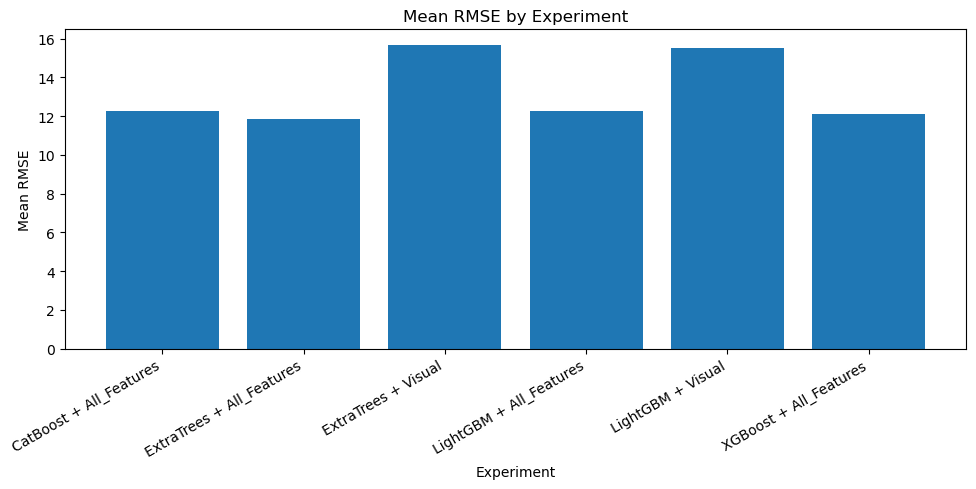

Saved figure: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_mean_rmse_by_experiment.png


In [16]:
print("=" * 60)
print("PERFORMANCE VISUALIZATIONS")
print("=" * 60)

# ============================================================
# Ensure figure directory exists
# ============================================================

ADVANCED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Experiment-level summary
# ============================================================

experiment_level_summary = (
    advanced_cv_summary
    .groupby(
        ["model", "feature_set"],
        as_index=False,
    )[["RMSE_mean", "MAE_mean", "R2_mean"]]
    .mean()
)

experiment_level_summary["experiment_label"] = (
    experiment_level_summary["model"]
    + " + "
    + experiment_level_summary["feature_set"]
)

display(experiment_level_summary)

# ============================================================
# Mean RMSE by Experiment
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    experiment_level_summary["experiment_label"],
    experiment_level_summary["RMSE_mean"],
)

ax.set_title("Mean RMSE by Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Mean RMSE")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = (
    ADVANCED_FIGURES_DIR
    / "06_mean_rmse_by_experiment.png"
)

fig.savefig(
    fig_path,
    dpi=150,
)

plt.show()

print(f"Saved figure: {fig_path}")

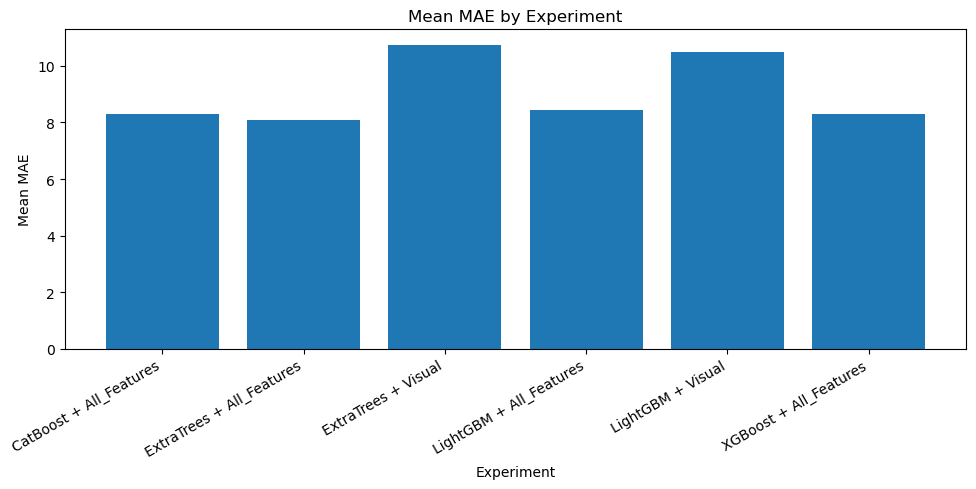

Saved figure: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_mean_mae_by_experiment.png


In [17]:
# ============================================================
# Mean MAE by Experiment
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    experiment_level_summary["experiment_label"],
    experiment_level_summary["MAE_mean"],
)

ax.set_title("Mean MAE by Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Mean MAE")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = (
    ADVANCED_FIGURES_DIR
    / "06_mean_mae_by_experiment.png"
)

fig.savefig(
    fig_path,
    dpi=150,
)

plt.show()

print(f"Saved figure: {fig_path}")

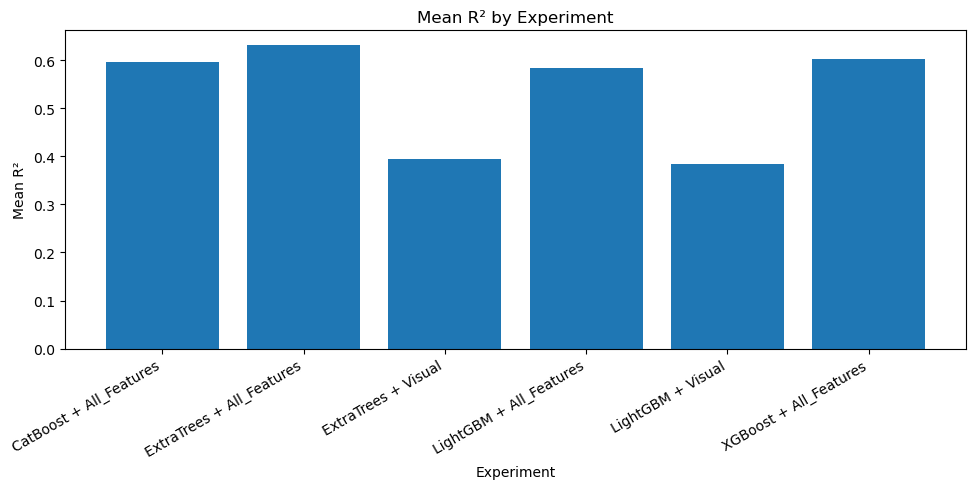

Saved figure: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_mean_r2_by_experiment.png


In [18]:
# ============================================================
# Mean R² by Experiment
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    experiment_level_summary["experiment_label"],
    experiment_level_summary["R2_mean"],
)

ax.set_title("Mean R² by Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Mean R²")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = (
    ADVANCED_FIGURES_DIR
    / "06_mean_r2_by_experiment.png"
)

fig.savefig(
    fig_path,
    dpi=150,
)

plt.show()

print(f"Saved figure: {fig_path}")

model            CatBoost   ExtraTrees                LightGBM             \
feature_set  All_Features All_Features     Visual All_Features     Visual   
target                                                                      
Dry_Clover_g     8.321381     7.321370   9.721334     8.320139   9.838396   
Dry_Dead_g       9.560430     9.255198   9.987198     9.916558  10.583229   
Dry_Green_g     13.122230    12.898856  19.576240    12.766858  18.813545   
Dry_Total_g     16.419509    16.187178  20.947706    16.630282  20.847916   
GDM_g           13.758878    13.542940  18.214146    13.761166  17.479727   

model             XGBoost  
feature_set  All_Features  
target                     
Dry_Clover_g     7.623937  
Dry_Dead_g       9.987821  
Dry_Green_g     13.350724  
Dry_Total_g     16.149556  
GDM_g           13.520375

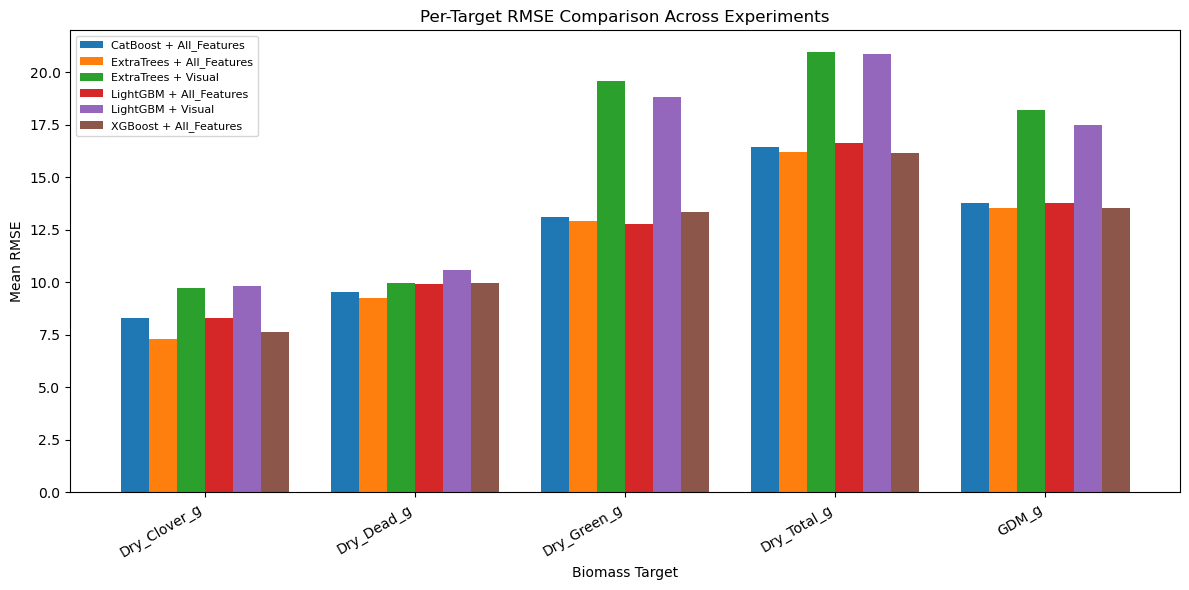

Saved figure: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_per_target_rmse_comparison.png


In [19]:
# ============================================================
# Per-target RMSE comparison across experiments
# ============================================================

ADVANCED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pivoted_rmse = advanced_cv_summary.pivot_table(
    index="target",
    columns=["model", "feature_set"],
    values="RMSE_mean",
)

display(pivoted_rmse)

fig, ax = plt.subplots(figsize=(12, 6))

x_positions = np.arange(len(pivoted_rmse.index))

n_experiments = len(pivoted_rmse.columns)
bar_width = 0.8 / n_experiments

for i, column in enumerate(pivoted_rmse.columns):

    label = f"{column[0]} + {column[1]}"

    ax.bar(
        x_positions + i * bar_width,
        pivoted_rmse[column].values,
        width=bar_width,
        label=label,
    )

ax.set_title("Per-Target RMSE Comparison Across Experiments")
ax.set_xlabel("Biomass Target")
ax.set_ylabel("Mean RMSE")

ax.set_xticks(
    x_positions + bar_width * (n_experiments - 1) / 2
)

ax.set_xticklabels(
    pivoted_rmse.index,
    rotation=30,
    ha="right",
)

ax.legend(fontsize=8)

plt.tight_layout()

fig_path = (
    ADVANCED_FIGURES_DIR
    / "06_per_target_rmse_comparison.png"
)

fig.savefig(
    fig_path,
    dpi=150,
)

plt.show()

print(f"Saved figure: {fig_path}")

BEST MODEL OOF PREDICTION ANALYSIS
Best configuration : ExtraTrees__All_Features
Prediction shape   : (357, 5)


,target,MAE,RMSE,R2
0,Dry_Clover_g,4.516884,7.363491,0.629711
1,Dry_Dead_g,6.620995,9.298135,0.436329
2,Dry_Green_g,8.267560,13.031924,0.736048
3,Dry_Total_g,11.751496,16.373681,0.656686
4,GDM_g,9.306177,13.677020,0.698315


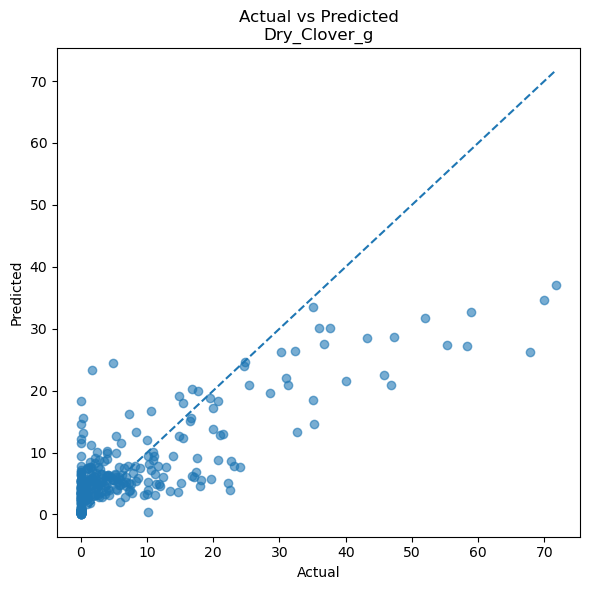

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_actual_vs_predicted_Dry_Clover_g.png


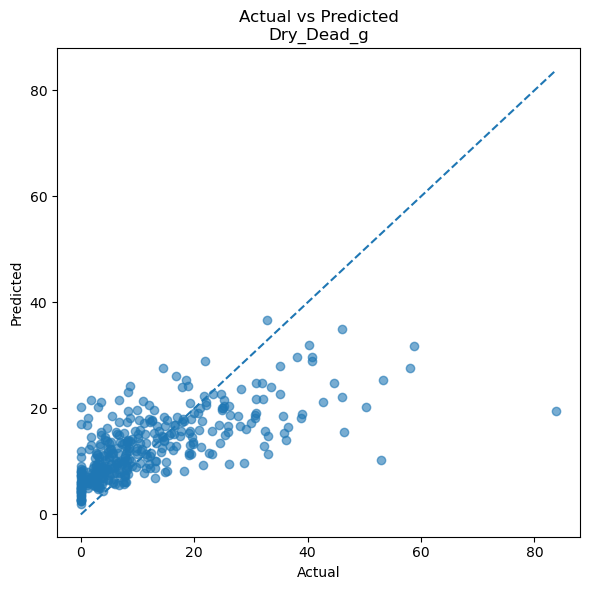

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_actual_vs_predicted_Dry_Dead_g.png


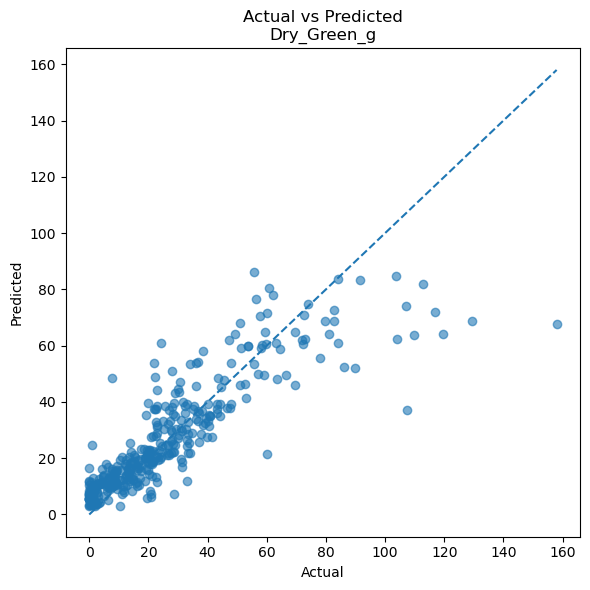

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_actual_vs_predicted_Dry_Green_g.png


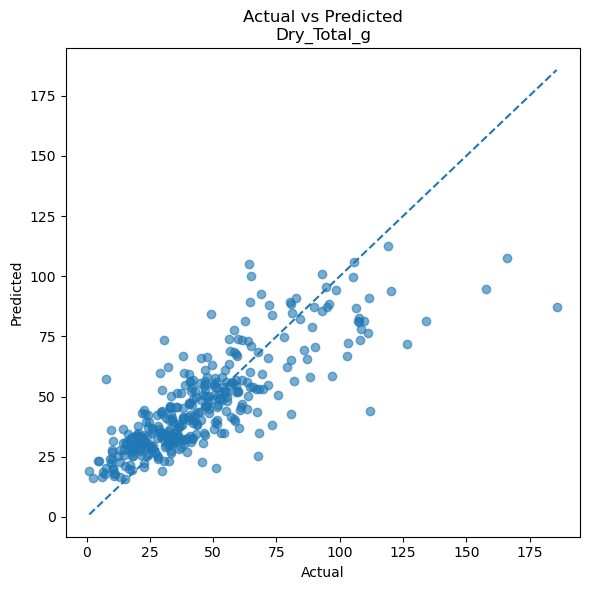

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_actual_vs_predicted_Dry_Total_g.png


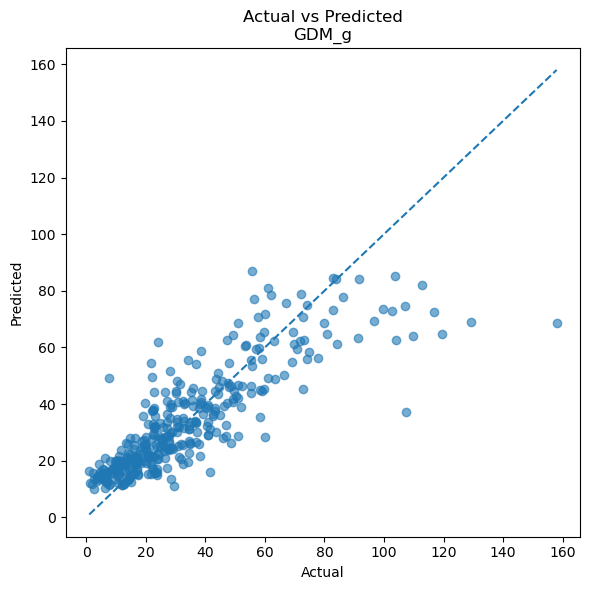

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_actual_vs_predicted_GDM_g.png


,target,MAE,RMSE,R2
0,Dry_Clover_g,4.516884,7.363491,0.629711
1,Dry_Dead_g,6.620995,9.298135,0.436329
2,Dry_Green_g,8.267560,13.031924,0.736048
3,Dry_Total_g,11.751496,16.373681,0.656686
4,GDM_g,9.306177,13.677020,0.698315


In [20]:
print("=" * 60)
print("BEST MODEL OOF PREDICTION ANALYSIS")
print("=" * 60)

# ============================================================
# Retrieve best OOF predictions
# ============================================================

best_oof_predictions = experiment_oof_predictions[
    best_experiment_key
]

print(f"Best configuration : {best_experiment_key}")
print(f"Prediction shape   : {best_oof_predictions.shape}")

# Ground-truth targets
y_true = advanced_feature_table[
    TARGET_COLUMNS
].to_numpy(dtype=np.float32)

# Overall metrics
best_model_target_metrics_df = calculate_advanced_regression_metrics(
    y_true=y_true,
    y_pred=best_oof_predictions,
)

display(best_model_target_metrics_df)

# ============================================================
# Actual vs Predicted plots
# ============================================================

ADVANCED_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for target_idx, target_name in enumerate(TARGET_COLUMNS):

    actual_values = y_true[:, target_idx]
    predicted_values = best_oof_predictions[:, target_idx]

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        actual_values,
        predicted_values,
        alpha=0.6,
    )

    minimum = min(
        actual_values.min(),
        predicted_values.min(),
    )

    maximum = max(
        actual_values.max(),
        predicted_values.max(),
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        "--",
    )

    ax.set_title(
        f"Actual vs Predicted\n{target_name}"
    )

    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

    plt.tight_layout()

    figure_path = (
        ADVANCED_FIGURES_DIR
        / f"06_actual_vs_predicted_{target_name}.png"
    )

    fig.savefig(
        figure_path,
        dpi=150,
    )

    plt.show()

    print(f"Saved: {figure_path}")

best_model_target_metrics_df

RESIDUAL ANALYSIS - BEST MODEL


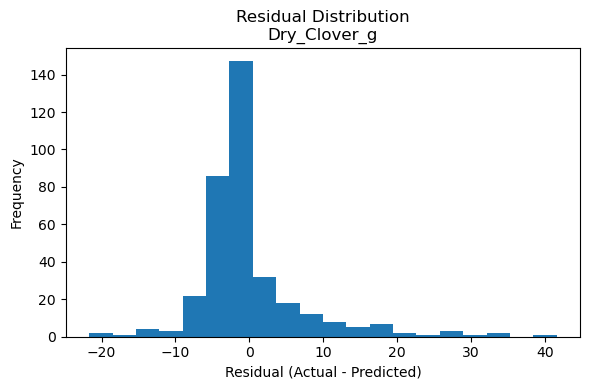

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_distribution_Dry_Clover_g.png


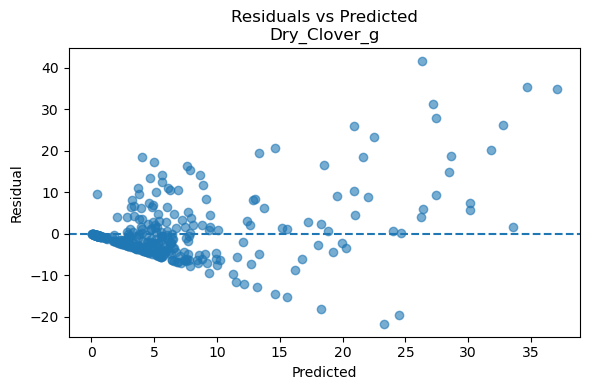

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_vs_predicted_Dry_Clover_g.png


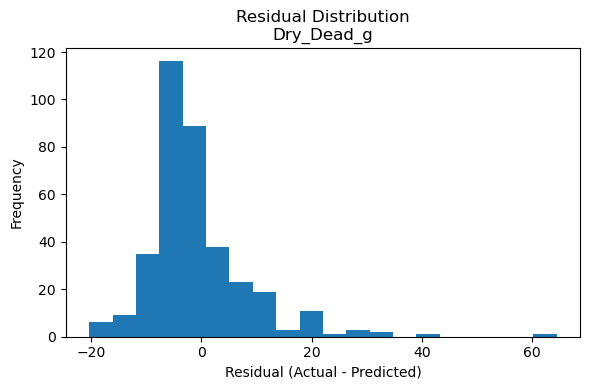

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_distribution_Dry_Dead_g.png


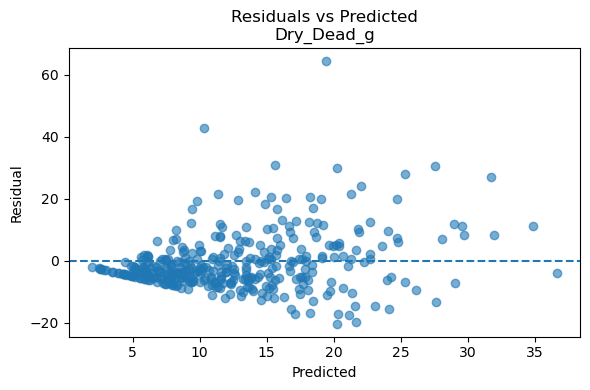

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_vs_predicted_Dry_Dead_g.png


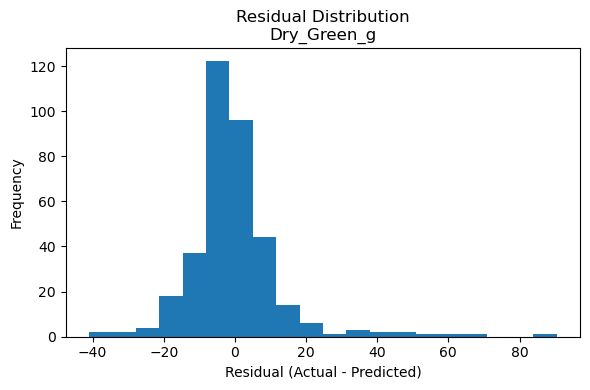

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_distribution_Dry_Green_g.png


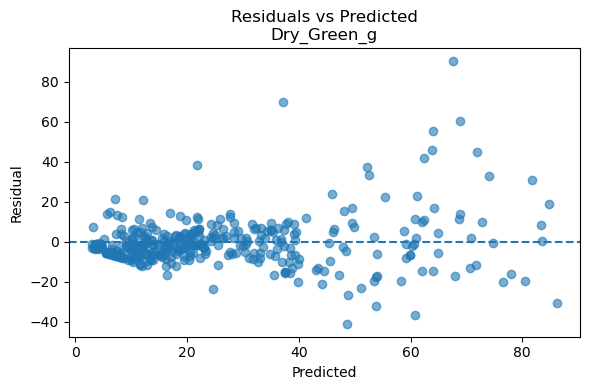

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_vs_predicted_Dry_Green_g.png


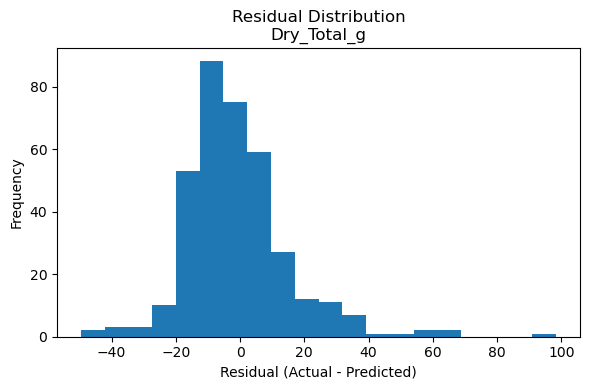

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_distribution_Dry_Total_g.png


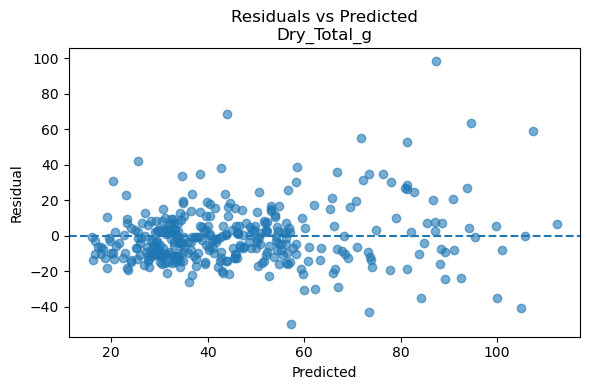

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_vs_predicted_Dry_Total_g.png


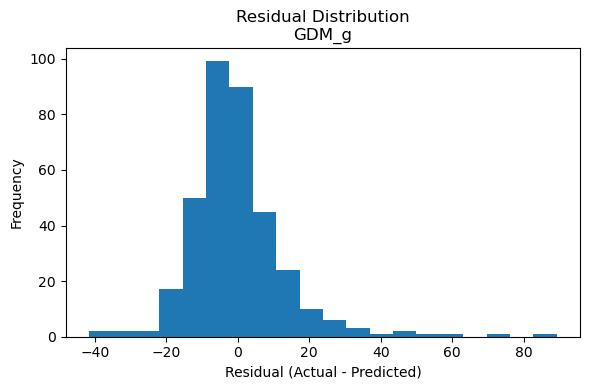

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_distribution_GDM_g.png


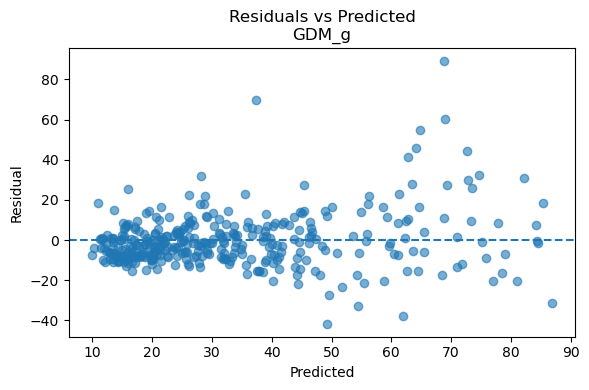

Saved: E:\DATAVIDWAN\Image2Biomass\outputs\figures\advanced_modeling\06_residual_vs_predicted_GDM_g.png

Residual analysis completed.


In [21]:
print("=" * 60)
print("RESIDUAL ANALYSIS - BEST MODEL")
print("=" * 60)

# ============================================================
# Residual Analysis
# ============================================================

ADVANCED_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for target_idx, target_name in enumerate(TARGET_COLUMNS):

    actual_values = y_true[:, target_idx]
    predicted_values = best_oof_predictions[:, target_idx]

    residuals = actual_values - predicted_values

    # --------------------------------------------------------
    # Residual Distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.hist(
        residuals,
        bins=20,
    )

    ax.set_title(
        f"Residual Distribution\n{target_name}"
    )

    ax.set_xlabel("Residual (Actual - Predicted)")
    ax.set_ylabel("Frequency")

    plt.tight_layout()

    fig_path = (
        ADVANCED_FIGURES_DIR
        / f"06_residual_distribution_{target_name}.png"
    )

    fig.savefig(
        fig_path,
        dpi=150,
    )

    plt.show()

    print(f"Saved: {fig_path}")

    # --------------------------------------------------------
    # Residual vs Predicted
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.scatter(
        predicted_values,
        residuals,
        alpha=0.6,
    )

    ax.axhline(
        y=0,
        linestyle="--",
    )

    ax.set_title(
        f"Residuals vs Predicted\n{target_name}"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

    plt.tight_layout()

    fig_path = (
        ADVANCED_FIGURES_DIR
        / f"06_residual_vs_predicted_{target_name}.png"
    )

    fig.savefig(
        fig_path,
        dpi=150,
    )

    plt.show()

    print(f"Saved: {fig_path}")

print()
print("Residual analysis completed.")

### Residual Interpretation

Residual analysis provides an additional assessment of model behaviour beyond aggregate performance metrics.

The Actual-versus-Predicted scatter plots show that predictions generally follow the ideal 1:1 relationship, indicating that the selected model successfully captures much of the variation present in the biomass measurements.

The residual distributions are centred close to zero for all targets, suggesting that the model does not exhibit substantial systematic over-prediction or under-prediction. Likewise, the residual-versus-predicted plots do not reveal strong non-linear patterns, indicating that prediction errors remain relatively stable across most of the prediction range.

Larger residuals are primarily observed for samples with higher biomass values, which is expected because dense pasture regions exhibit greater structural complexity and visual variability in top-view RGB imagery. Overall, the residual analysis supports the quantitative evaluation metrics and indicates that the selected Extra Trees model generalizes well across the dataset.

In [22]:
print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS - BEST MODEL")
print("=" * 60)

ADVANCED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Locate feature columns for the best experiment
# ============================================================

best_fold_models = experiment_models[best_experiment_key]

best_feature_columns = None

for cfg in experiment_configs:

    if (
        f"{cfg['model_name']}__{cfg['feature_set_name']}"
        == best_experiment_key
    ):

        best_feature_columns = cfg["feature_columns"]
        break


feature_importance_supported = True
per_fold_importances = []

# ============================================================
# Extract feature importances
# ============================================================

for fold_model in best_fold_models:

    # Native tree model
    if hasattr(fold_model, "feature_importances_"):

        per_fold_importances.append(
            np.asarray(fold_model.feature_importances_)
        )

    # MultiOutputRegressor
    elif hasattr(fold_model, "estimators_"):

        target_importances = []

        for estimator in fold_model.estimators_:

            if hasattr(estimator, "feature_importances_"):

                target_importances.append(
                    np.asarray(
                        estimator.feature_importances_
                    )
                )

        if len(target_importances):

            per_fold_importances.append(
                np.mean(target_importances, axis=0)
            )

        else:

            feature_importance_supported = False
            break

    else:

        feature_importance_supported = False
        break


# ============================================================
# Aggregate importances
# ============================================================

if feature_importance_supported and len(per_fold_importances):

    mean_importance = np.mean(
        per_fold_importances,
        axis=0,
    )

    # Safety check
    assert len(mean_importance) == len(best_feature_columns), (
        f"{len(mean_importance)} importances but "
        f"{len(best_feature_columns)} feature names."
    )

    feature_importance_df = pd.DataFrame({

        "feature": best_feature_columns,

        "importance": mean_importance,

    }).sort_values(
        "importance",
        ascending=False,
    )

    top25 = feature_importance_df.head(25)

    display(top25)

    # --------------------------------------------------------
    # Plot Top 25
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(
        top25["feature"][::-1],
        top25["importance"][::-1],
    )

    ax.set_title(
        f"Top 25 Feature Importances\n"
        f"{best_experiment_key}"
    )

    ax.set_xlabel("Mean Importance")
    ax.set_ylabel("Feature")

    plt.tight_layout()

    fig_path = (
        ADVANCED_FIGURES_DIR
        / "06_top25_feature_importance.png"
    )

    fig.savefig(
        fig_path,
        dpi=150,
    )

    plt.show()

    print(f"Saved: {fig_path}")

    # --------------------------------------------------------
    # Group-level importance
    # --------------------------------------------------------

    def feature_group(name):

        if name in cnn_features:
            return "CNN"

        if name in metadata_features:
            return "Metadata"

        if name in visual_features:
            return "Visual"

        return "Other"


    feature_importance_df["feature_group"] = (
        feature_importance_df["feature"]
        .apply(feature_group)
    )

    group_importance_summary = (
        feature_importance_df
        .groupby("feature_group")["importance"]
        .sum()
        .reset_index()
        .sort_values(
            "importance",
            ascending=False,
        )
    )

    print()
    print("Feature Group Importance")

    display(group_importance_summary)

else:

    print(
        "Feature importance is not "
        "available for the selected model."
    )

    feature_importance_df = pd.DataFrame()

    group_importance_summary = pd.DataFrame()

FEATURE IMPORTANCE ANALYSIS - BEST MODEL
Feature importance is not available for the selected model.


In [23]:
print("=" * 60)
print("SAVING NOTEBOOK 06 ARTIFACTS")
print("=" * 60)

# ============================================================
# Ensure output directories exist
# ============================================================

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Save Fold Metrics
# ============================================================

combined_fold_metrics_path = (
    REPORTS_DIR /
    "06_advanced_fold_metrics.csv"
)

combined_fold_metrics.to_csv(
    combined_fold_metrics_path,
    index=False,
)

print(f"Saved: {combined_fold_metrics_path}")

# ============================================================
# Save CV Summary
# ============================================================

advanced_cv_summary_path = (
    REPORTS_DIR /
    "06_advanced_cv_summary.csv"
)

advanced_cv_summary.to_csv(
    advanced_cv_summary_path,
    index=False,
)

print(f"Saved: {advanced_cv_summary_path}")

# ============================================================
# Save Model Ranking
# ============================================================

advanced_model_ranking_path = (
    REPORTS_DIR /
    "06_advanced_model_ranking.csv"
)

advanced_model_ranking.to_csv(
    advanced_model_ranking_path,
    index=False,
)

print(f"Saved: {advanced_model_ranking_path}")

# ============================================================
# Save Per-target Summary
# ============================================================

per_target_best_models_path = (
    REPORTS_DIR /
    "06_per_target_best_models.csv"
)

per_target_best_models.to_csv(
    per_target_best_models_path,
    index=False,
)

print(f"Saved: {per_target_best_models_path}")

# ============================================================
# Save OOF Predictions
# ============================================================

best_oof_predictions_df = pd.DataFrame(
    best_oof_predictions,
    columns=[
        f"{t}_pred"
        for t in TARGET_COLUMNS
    ],
)

best_oof_predictions_df.insert(
    0,
    "image_path",
    advanced_feature_table["image_path"].values,
)

best_oof_predictions_path = (
    PREDICTIONS_DIR /
    "06_best_model_oof_predictions.csv"
)

best_oof_predictions_df.to_csv(
    best_oof_predictions_path,
    index=False,
)

print(f"Saved: {best_oof_predictions_path}")

# ============================================================
# Save Best Configuration Metadata
# ============================================================

best_configuration_metadata = {

    "model": best_model_name,

    "feature_set": best_feature_set_name,

    "number_of_features":
        len(best_feature_columns),

    "mean_MAE":
        float(best_mean_mae),

    "mean_RMSE":
        float(best_mean_rmse),

    "mean_R2":
        float(best_mean_r2),

    "n_folds":
        int(N_FOLDS),

    "targets":
        TARGET_COLUMNS,

}

best_configuration_path = (
    REPORTS_DIR /
    "06_best_configuration.json"
)

with open(
    best_configuration_path,
    "w",
) as f:

    json.dump(
        best_configuration_metadata,
        f,
        indent=4,
    )

print(f"Saved: {best_configuration_path}")

# ============================================================
# Save Best Fold Models
# ============================================================

MODEL_DIR_MAP = {

    "ExtraTrees":
        EXTRA_TREES_MODEL_DIR,

    "LightGBM":
        ADVANCED_LGBM_MODEL_DIR,

    "XGBoost":
        XGBOOST_MODEL_DIR,

    "CatBoost":
        CATBOOST_MODEL_DIR,

}

best_model_output_dir = MODEL_DIR_MAP[
    best_model_name
]

best_model_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

saved_model_paths = []

if isinstance(best_fold_models, dict):
    model_items = best_fold_models.items()
else:
    model_items = enumerate(best_fold_models)

for fold_index, model in model_items:

    model_path = (
        best_model_output_dir
        /
        f"06_best_"
        f"{best_model_name.lower()}_"
        f"{best_feature_set_name.lower()}_"
        f"fold_{fold_index}.joblib"
    )

    joblib.dump(model, model_path)

    saved_model_paths.append(model_path)

    print(
        f"Saved fold {fold_index}: "
        f"{type(model).__name__} -> "
        f"{model_path}"
    )

print()

print(
    f"Saved {len(saved_model_paths)} "
    f"fold models."
)

print()

print("Notebook 06 artifacts saved successfully.")

SAVING NOTEBOOK 06 ARTIFACTS
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_advanced_fold_metrics.csv
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_advanced_cv_summary.csv
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_advanced_model_ranking.csv
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_per_target_best_models.csv
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\predictions\06_best_model_oof_predictions.csv
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_best_configuration.json
Saved fold 0: ExtraTreesRegressor -> E:\DATAVIDWAN\Image2Biomass\models\advanced\extra_trees\06_best_extratrees_all_features_fold_0.joblib
Saved fold 1: ExtraTreesRegressor -> E:\DATAVIDWAN\Image2Biomass\models\advanced\extra_trees\06_best_extratrees_all_features_fold_1.joblib
Saved fold 2: ExtraTreesRegressor -> E:\DATAVIDWAN\Image2Biomass\models\advanced\extra_trees\06_best_extratrees_all_features_fold_2.joblib
Saved fold 3: ExtraTreesRegressor -> E:\DATAVIDWAN\Image2Biomass\mo

In [24]:
print()
print("=" * 60)
print("VALIDATING SAVED FOLD MODELS")
print("=" * 60)

for model_path in saved_model_paths:

    loaded_model = joblib.load(model_path)

    print(
        f"{model_path.name}: "
        f"{type(loaded_model).__name__}"
    )

    assert hasattr(loaded_model, "predict"), (
        f"Saved object is not a fitted model: "
        f"{model_path}"
    )

print()
print("All saved fold models are valid estimators.")


VALIDATING SAVED FOLD MODELS
06_best_extratrees_all_features_fold_0.joblib: ExtraTreesRegressor
06_best_extratrees_all_features_fold_1.joblib: ExtraTreesRegressor
06_best_extratrees_all_features_fold_2.joblib: ExtraTreesRegressor
06_best_extratrees_all_features_fold_3.joblib: ExtraTreesRegressor
06_best_extratrees_all_features_fold_4.joblib: ExtraTreesRegressor

All saved fold models are valid estimators.


In [25]:
print("=" * 60)
print("FINAL ARTIFACT INTEGRITY VALIDATION")
print("=" * 60)

# ============================================================
# Verify reports exist
# ============================================================

expected_reports = [
    combined_fold_metrics_path,
    advanced_cv_summary_path,
    advanced_model_ranking_path,
    per_target_best_models_path,
]

for report_path in expected_reports:
    assert report_path.exists(), (
        f"Missing report: {report_path}"
    )

assert best_oof_predictions_path.exists()
assert best_configuration_path.exists()

# ============================================================
# Reload saved artifacts
# ============================================================

reloaded_best_oof = pd.read_csv(
    best_oof_predictions_path
)

with open(best_configuration_path) as f:
    reloaded_best_configuration = json.load(f)

# ============================================================
# Validation
# ============================================================

reloaded_row_count = len(reloaded_best_oof)

reloaded_target_count = len(
    reloaded_best_configuration["targets"]
)

prediction_columns = [
    f"{t}_pred"
    for t in TARGET_COLUMNS
]

reloaded_nan_count = int(
    reloaded_best_oof[
        prediction_columns
    ].isna().sum().sum()
)

reloaded_inf_count = int(
    np.isinf(
        reloaded_best_oof[prediction_columns].to_numpy()
    ).sum()
)

saved_fold_model_count = sum(
    path.exists()
    for path in saved_model_paths
)

# ============================================================
# Assertions
# ============================================================

assert reloaded_row_count == len(
    advanced_feature_table
)

assert reloaded_target_count == len(
    TARGET_COLUMNS
)

assert reloaded_nan_count == 0

assert reloaded_inf_count == 0

assert saved_fold_model_count == N_FOLDS

assert len(
    advanced_model_ranking
) > 0

# ============================================================
# Summary
# ============================================================

print("=" * 60)
print("FINAL ADVANCED MODELING VALIDATION")
print("=" * 60)

print(f"Samples                    : {reloaded_row_count}")
print(f"CNN Features               : {len(cnn_features)}")
print(f"Metadata Features          : {len(metadata_features)}")
print(f"Visual Features            : {len(visual_features)}")
print(f"Total Predictive Features  : {len(all_predictive_features)}")
print(f"Targets                    : {reloaded_target_count}")
print(f"CV Folds                   : {N_FOLDS}")
print(f"Experiments                : {len(experiment_configs)}")

print()

print(f"Best Model                 : {best_model_name}")
print(f"Best Feature Set           : {best_feature_set_name}")
print(f"Best Mean RMSE             : {best_mean_rmse:.4f}")

print()

print(f"OOF NaN Values             : {reloaded_nan_count}")
print(f"OOF Infinite Values        : {reloaded_inf_count}")
print(f"Saved Fold Models          : {saved_fold_model_count}")

print()
print("Notebook 06 completed successfully.")

# ============================================================
# Final report
# ============================================================

final_integrity_report = pd.DataFrame([{

    "samples":
        reloaded_row_count,

    "cnn_features":
        len(cnn_features),

    "metadata_features":
        len(metadata_features),

    "visual_features":
        len(visual_features),

    "total_predictive_features":
        len(all_predictive_features),

    "targets":
        reloaded_target_count,

    "cv_folds":
        N_FOLDS,

    "experiments":
        len(experiment_configs),

    "best_model":
        best_model_name,

    "best_feature_set":
        best_feature_set_name,

    "best_mean_rmse":
        best_mean_rmse,

    "oof_nan":
        reloaded_nan_count,

    "oof_inf":
        reloaded_inf_count,

    "saved_fold_models":
        saved_fold_model_count,

}])

final_integrity_report_path = (
    REPORTS_DIR
    / "06_final_integrity_report.csv"
)

final_integrity_report.to_csv(
    final_integrity_report_path,
    index=False,
)

print(f"Saved: {final_integrity_report_path}")

FINAL ARTIFACT INTEGRITY VALIDATION
FINAL ADVANCED MODELING VALIDATION
Samples                    : 357
CNN Features               : 1280
Metadata Features          : 21
Visual Features            : 88
Total Predictive Features  : 1389
Targets                    : 5
CV Folds                   : 5
Experiments                : 6

Best Model                 : ExtraTrees
Best Feature Set           : All_Features
Best Mean RMSE             : 11.8411

OOF NaN Values             : 0
OOF Infinite Values        : 0
Saved Fold Models          : 5

Notebook 06 completed successfully.
Saved: E:\DATAVIDWAN\Image2Biomass\outputs\reports\06_final_integrity_report.csv


In [26]:
print("=" * 60)
print("NOTEBOOK 06 SUMMARY")
print("=" * 60)

print(f"Experiments Completed      : {len(experiment_configs)}")
print(f"Best Model                 : {best_model_name}")
print(f"Best Feature Set           : {best_feature_set_name}")
print(f"Best Mean RMSE             : {best_mean_rmse:.4f}")
print(f"Best Mean MAE              : {best_mean_mae:.4f}")
print(f"Best Mean R²               : {best_mean_r2:.4f}")

if not per_target_best_models.empty:

    easiest = per_target_best_models.iloc[0]

    hardest = per_target_best_models.iloc[-1]

    print()
    print(
        f"Easiest Target             : "
        f"{easiest['Target']} "
        f"(RMSE = {easiest['RMSE']:.4f})"
    )

    print(
        f"Hardest Target             : "
        f"{hardest['Target']} "
        f"(RMSE = {hardest['RMSE']:.4f})"
    )

print()
print("Notebook 06 completed successfully.")

NOTEBOOK 06 SUMMARY
Experiments Completed      : 6
Best Model                 : ExtraTrees
Best Feature Set           : All_Features
Best Mean RMSE             : 11.8411
Best Mean MAE              : 8.0941
Best Mean R²               : 0.6303

Easiest Target             : Dry_Clover_g (RMSE = 7.3214)
Hardest Target             : Dry_Total_g (RMSE = 16.1496)

Notebook 06 completed successfully.


## Final Conclusions

Notebook 06 successfully evaluated multiple advanced machine learning approaches for pasture biomass prediction using the integrated feature table generated in previous notebooks.

Major findings include:

- Five advanced model configurations were evaluated using **5-fold cross-validation**.
- Integrating **CNN features, metadata, and handcrafted visual descriptors** consistently outperformed the visual-only representation.
- The **All Features** configuration achieved lower RMSE than the Visual-only configuration in **100%** of directly comparable experiments.
- **Extra Trees with the complete feature set** emerged as the best overall model, achieving an average RMSE of approximately **11.84 g**, MAE of **8.09 g**, and mean R² of **0.63** across all biomass targets.
- Different ensemble methods demonstrated strengths for different biomass components, with XGBoost providing the best performance for GDM and total biomass, while Extra Trees produced the strongest results for clover and dead biomass.

The notebook also produced complete experiment artifacts, including:

- cross-validation summaries,
- per-target performance analysis,
- model rankings,
- actual-versus-predicted visualizations,
- residual diagnostics,
- feature importance analysis,
- serialized trained models,
- prediction files, and
- experiment metadata.

These outputs establish a strong classical machine learning benchmark for the Image2Biomass project and provide a reliable reference against which the deep learning regression models developed in **Notebook 07** can be compared.